In [1]:
library(dplyr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
CA1_path <- "./03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass/CA1/"
CA1_files <- list.files(path = CA1_path, pattern = "\\.tmp$", full.names = TRUE)
CA1_files

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_FC_L2_3.mm10.tmp"   
[2] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_FC_L4_Rorb.mm10.tmp"
[3] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_FC_L5.mm10.tmp"     
[4] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_FC_L6.mm10.tmp"     
[5] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_HC_CA1.mm10.tmp"    
[6] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_HC_CA23.mm10.tmp"   
[7] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_HC_DG.mm10.tmp"     
[8] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_In_Pvalb.mm10.tmp"  
[9] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass/CA1//Paired-Tag_H3K27me3_In_Sst.mm10.tmp"

In [3]:
merged_CA1 <- NULL

In [4]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K27me3_FC_CT.mm10.tmp")

[1] "CT"

In [5]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K27me3_FC_L2_3.mm10.tmp")

[1] "L2_3"

In [6]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K27me3_HC_DG.mm10.tmp")
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K27me3_In_Pvalb.mm10.tmp")

[1] "DG"

[1] "Pvalb"

In [7]:
for (file in CA1_files) {

  base_name <- gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$", "\\2", basename(file))
  print(base_name)

  tmp_data <- read.table(file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

  if (!is.null(merged_CA1)) {
    if (!identical(merged_CA1[, 1], tmp_data[, 1])) {
      stop(paste("The first column in file", file, "is not identical to the previous files!"))
    }
  }

  colnames(tmp_data)[2:3] <- paste(base_name, colnames(tmp_data)[2:3], sep = "_")

  if (is.null(merged_CA1)) {
    merged_CA1 <- tmp_data
  } else {
    merged_CA1 <- cbind(merged_CA1, tmp_data[, -1])
  }
}

[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "Pvalb"
[1] "Sst"


In [8]:
merged_CA1

hyperDHMR,L2_3_signal_sum,L2_3_signal_sum_log10,L4_Rorb_signal_sum,L4_Rorb_signal_sum_log10,L5_signal_sum,L5_signal_sum_log10,L6_signal_sum,L6_signal_sum_log10,CA1_signal_sum,CA1_signal_sum_log10,CA23_signal_sum,CA23_signal_sum_log10,DG_signal_sum,DG_signal_sum_log10,Pvalb_signal_sum,Pvalb_signal_sum_log10,Sst_signal_sum,Sst_signal_sum_log10
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.00000,0.0000000,0.00000,0.000000,0.000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.0000000,0.0000,0.000000,0.0000,0.000000
chr1:4794017-4795017,0.00000,0.0000000,0.00000,0.000000,0.000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.0000000,0.0000,0.000000,0.0000,0.000000
chr1:4947085-4948085,0.00000,0.0000000,0.00000,0.000000,0.000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.0000000,0.0000,0.000000,0.0000,0.000000
chr1:5336791-5337791,37.10440,1.5809751,76.84880,1.891252,0.000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.0000000,0.0000,0.000000,0.0000,0.000000
chr1:5745992-5746992,0.59367,0.2023984,0.00000,0.000000,0.000,0.000000,0.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.0000000,316.8500,2.502222,388.3601,2.590351
chr1:5825616-5826616,37.10440,1.5809751,0.00000,0.000000,0.000,0.000000,0.00000,0.000000,268.29200,2.430223,238.63600,2.379552,77.669469,1.8958062,0.0000,0.000000,0.0000,0.000000
chr1:6177024-6178024,148.41740,2.1744012,75.00443,1.880839,0.000,0.000000,136.83020,2.139344,132.53585,2.125598,120.74941,2.085467,3.026083,0.6048827,0.0000,0.000000,0.0000,0.000000
chr1:7060591-7061591,59.03310,1.7783908,0.00000,0.000000,0.000,0.000000,0.00000,0.000000,67.07280,1.832974,0.00000,0.000000,77.354170,1.8940621,0.0000,0.000000,391.4920,2.593831
chr1:8211551-8212551,0.00000,0.0000000,76.84880,1.891252,0.000,0.000000,61.43676,1.795440,0.00000,0.000000,59.65880,1.782894,63.043400,1.8064744,142.2656,2.156142,0.0000,0.000000


In [9]:
merged_CA1 <- merged_CA1[, c(1, grep("signal_sum_log10", colnames(merged_CA1)))]

merged_CA1

hyperDHMR,L2_3_signal_sum_log10,L4_Rorb_signal_sum_log10,L5_signal_sum_log10,L6_signal_sum_log10,CA1_signal_sum_log10,CA23_signal_sum_log10,DG_signal_sum_log10,Pvalb_signal_sum_log10,Sst_signal_sum_log10
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4794017-4795017,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4947085-4948085,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:5336791-5337791,1.5809751,1.891252,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:5745992-5746992,0.2023984,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,2.502222,2.590351
chr1:5825616-5826616,1.5809751,0.000000,0.000000,0.000000,2.430223,2.379552,1.8958062,0.000000,0.000000
chr1:6177024-6178024,2.1744012,1.880839,0.000000,2.139344,2.125598,2.085467,0.6048827,0.000000,0.000000
chr1:7060591-7061591,1.7783908,0.000000,0.000000,0.000000,1.832974,0.000000,1.8940621,0.000000,2.593831
chr1:8211551-8212551,0.0000000,1.891252,0.000000,1.795440,0.000000,1.782894,1.8064744,2.156142,0.000000


In [10]:
library(tidyverse)

Warning message:
“package ‘tidyverse’ was built under R version 4.3.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘readr’ was built under R version 4.3.3”
Warning message:
“package ‘stringr’ was built under R version 4.3.2”
Warning message:
“package ‘forcats’ was built under R version 4.3.3”
── Attaching core tidyverse packages ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.2     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.0
── Conflicts ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all

In [11]:
merged_CA1 <- merged_CA1 %>% column_to_rownames("hyperDHMR")
merged_CA1

,L2_3_signal_sum_log10,L4_Rorb_signal_sum_log10,L5_signal_sum_log10,L6_signal_sum_log10,CA1_signal_sum_log10,CA23_signal_sum_log10,DG_signal_sum_log10,Pvalb_signal_sum_log10,Sst_signal_sum_log10
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4794017-4795017,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4947085-4948085,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:5336791-5337791,1.5809751,1.891252,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:5745992-5746992,0.2023984,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,2.502222,2.590351
chr1:5825616-5826616,1.5809751,0.000000,0.000000,0.000000,2.430223,2.379552,1.8958062,0.000000,0.000000
chr1:6177024-6178024,2.1744012,1.880839,0.000000,2.139344,2.125598,2.085467,0.6048827,0.000000,0.000000
chr1:7060591-7061591,1.7783908,0.000000,0.000000,0.000000,1.832974,0.000000,1.8940621,0.000000,2.593831
chr1:8211551-8212551,0.0000000,1.891252,0.000000,1.795440,0.000000,1.782894,1.8064744,2.156142,0.000000


In [12]:
colnames(merged_CA1) <- gsub("_signal_sum_log10$","",colnames(merged_CA1))
merged_CA1

,L2_3,L4_Rorb,L5,L6,CA1,CA23,DG,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4794017-4795017,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4947085-4948085,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:5336791-5337791,1.5809751,1.891252,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:5745992-5746992,0.2023984,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,2.502222,2.590351
chr1:5825616-5826616,1.5809751,0.000000,0.000000,0.000000,2.430223,2.379552,1.8958062,0.000000,0.000000
chr1:6177024-6178024,2.1744012,1.880839,0.000000,2.139344,2.125598,2.085467,0.6048827,0.000000,0.000000
chr1:7060591-7061591,1.7783908,0.000000,0.000000,0.000000,1.832974,0.000000,1.8940621,0.000000,2.593831
chr1:8211551-8212551,0.0000000,1.891252,0.000000,1.795440,0.000000,1.782894,1.8064744,2.156142,0.000000


In [13]:
colnames(merged_CA1)[which(colnames(merged_CA1) %in% "L4_Rorb")] <- "L4"

In [14]:
merged_CA1

,L2_3,L4,L5,L6,CA1,CA23,DG,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4794017-4795017,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4947085-4948085,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:5336791-5337791,1.5809751,1.891252,0.000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:5745992-5746992,0.2023984,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,2.502222,2.590351
chr1:5825616-5826616,1.5809751,0.000000,0.000000,0.000000,2.430223,2.379552,1.8958062,0.000000,0.000000
chr1:6177024-6178024,2.1744012,1.880839,0.000000,2.139344,2.125598,2.085467,0.6048827,0.000000,0.000000
chr1:7060591-7061591,1.7783908,0.000000,0.000000,0.000000,1.832974,0.000000,1.8940621,0.000000,2.593831
chr1:8211551-8212551,0.0000000,1.891252,0.000000,1.795440,0.000000,1.782894,1.8064744,2.156142,0.000000


In [15]:
merged_CA1$merge_L5 <- (merged_CA1$L5+merged_CA1$L6)/2
merged_CA1 <- merged_CA1 %>% dplyr::select(-c(L5,L6))
colnames(merged_CA1)[which(colnames(merged_CA1) == "merge_L5")] <- "L5"
merged_CA1

,L2_3,L4,CA1,CA23,DG,Pvalb,Sst,L5
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000
chr1:4794017-4795017,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000
chr1:4947085-4948085,0.0000000,0.000000,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000
chr1:5336791-5337791,1.5809751,1.891252,0.000000,0.000000,0.0000000,0.000000,0.000000,0.0000000
chr1:5745992-5746992,0.2023984,0.000000,0.000000,0.000000,0.0000000,2.502222,2.590351,0.0000000
chr1:5825616-5826616,1.5809751,0.000000,2.430223,2.379552,1.8958062,0.000000,0.000000,0.0000000
chr1:6177024-6178024,2.1744012,1.880839,2.125598,2.085467,0.6048827,0.000000,0.000000,1.0696722
chr1:7060591-7061591,1.7783908,0.000000,1.832974,0.000000,1.8940621,0.000000,2.593831,0.0000000
chr1:8211551-8212551,0.0000000,1.891252,0.000000,1.782894,1.8064744,2.156142,0.000000,0.8977202


In [16]:
# celltype_order <- c("L2_3","L4","L5","L6","CA1","CA23","DG","Pvalb","Sst")
celltype_order <- c("L2_3","L4","L5","CA1","CA23","DG","Pvalb","Sst")
celltype_order

[1] "L2_3"  "L4"    "L5"    "CA1"   "CA23"  "DG"    "Pvalb" "Sst"

In [17]:
merged_CA1 <- merged_CA1[,celltype_order]
merged_CA1

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4794017-4795017,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4947085-4948085,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:5336791-5337791,1.5809751,1.891252,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:5745992-5746992,0.2023984,0.000000,0.0000000,0.000000,0.000000,0.0000000,2.502222,2.590351
chr1:5825616-5826616,1.5809751,0.000000,0.0000000,2.430223,2.379552,1.8958062,0.000000,0.000000
chr1:6177024-6178024,2.1744012,1.880839,1.0696722,2.125598,2.085467,0.6048827,0.000000,0.000000
chr1:7060591-7061591,1.7783908,0.000000,0.0000000,1.832974,0.000000,1.8940621,0.000000,2.593831
chr1:8211551-8212551,0.0000000,1.891252,0.8977202,0.000000,1.782894,1.8064744,2.156142,0.000000


In [18]:
colMeans(merged_CA1) %>% data.frame() %>% t()

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
.,1.002424,0.7989475,0.3690549,0.6793684,0.774098,0.6818291,0.3526776,0.314892


In [19]:
process_files <- function(input_path, pattern = "\\.tmp$", celltype_order) {
  files <- list.files(path = input_path, pattern = pattern, full.names = TRUE)
  merged_data <- NULL

  for (file in files) {
    base_name <- gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$", "\\2", basename(file))
    print(base_name)

    tmp_data <- read.table(file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

    if (!is.null(merged_data)) {
      if (!identical(merged_data[, 1], tmp_data[, 1])) {
        stop(paste("The first column in file", file, "is not identical to the previous files!"))
      }
    }

    colnames(tmp_data)[2:3] <- paste(base_name, colnames(tmp_data)[2:3], sep = "_")

    if (is.null(merged_data)) {
      merged_data <- tmp_data
    } else {
      merged_data <- cbind(merged_data, tmp_data[, -1])
    }
  }

  merged_data <- merged_data[, c(1, grep("signal_sum_log10", colnames(merged_data)))]
  merged_data <- merged_data %>% column_to_rownames("hyperDHMR")
  colnames(merged_data) <- gsub("_signal_sum_log10$", "", colnames(merged_data))

  colnames(merged_data)[which(colnames(merged_data) %in% "L4_Rorb")] <- "L4"

  merged_data$merge_L5 <- (merged_data$L5+merged_data$L6)/2
  merged_data <- merged_data %>% dplyr::select(-c(L5,L6))
  colnames(merged_data)[which(colnames(merged_data) == "merge_L5")] <- "L5"

  celltype_order <- c("L2_3","L4","L5","CA1","CA23","DG","Pvalb","Sst")

  merged_data <- merged_data[, celltype_order]
  
  return(merged_data)
}

In [ ]:
H3K27me3_path <- "./03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass/"

In [21]:
subdirs <- list.dirs(path = H3K27me3_path, full.names = TRUE, recursive = FALSE)
subdirs

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass//CA1"  
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass//CA23" 
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass//DG"   
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass//L2_3" 
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass//L4_5" 
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass//L5"   
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass//Lamp5"
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass//Pvalb"
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass//Sncg" 
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass//Sst"

In [22]:
basename(subdirs)

[1] "CA1"   "CA23"  "DG"    "L2_3"  "L4_5"  "L5"    "Lamp5" "Pvalb" "Sncg" 
[10] "Sst"

In [ ]:
L2_3 <- process_files('./03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass/L2_3', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L2_3

[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:6943646-6944646,2.134440,0.000000,0.0000000,2.7815084,1.7828938,2.2248248,0.000000,0.000000
chr1:9780815-9781815,1.580975,1.803674,0.0000000,1.8329736,2.4760980,2.1041004,2.502222,0.000000
chr1:20575278-20576278,0.000000,0.000000,0.0000000,0.0000000,2.4902349,1.6676148,0.000000,0.000000
chr1:31350491-31351491,1.580975,1.891252,0.0000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000
chr1:31956491-31957491,0.000000,0.000000,0.9245455,0.0000000,0.0000000,2.1041004,0.000000,0.000000
chr1:35665086-35666086,0.000000,1.891252,0.0000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000
chr1:40205252-40206252,2.366758,0.000000,0.0000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000
chr1:41656765-41657765,0.000000,0.000000,0.0000000,0.0000000,0.0000000,0.0000000,0.000000,2.593831
chr1:41760547-41761547,0.000000,0.000000,0.0000000,0.0000000,2.4760980,0.0000000,0.000000,0.000000


In [24]:
L2_3_mean <- colMeans(L2_3) %>% data.frame() %>% t()
rownames(L2_3_mean) <- "L2_3"
L2_3_mean

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
L2_3,0.8876849,0.695556,0.4041391,0.8111246,0.7785008,0.7056857,0.4267015,0.2676209


In [ ]:
L4_5 <- process_files('./03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass/L4_5', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L4_5

[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3931138-3932138,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:7536517-7537517,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:9794519-9795519,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:14839073-14840073,0.000000,1.891252,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:14914779-14915779,2.251204,2.138978,2.382440,2.933550,2.563331,2.438413,2.802567,3.037011
chr1:18962969-18963969,1.580975,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:22023298-22024298,0.000000,0.000000,0.000000,0.000000,0.000000,2.080642,0.000000,0.000000
chr1:24906164-24907164,1.910058,0.000000,0.000000,0.000000,1.782894,1.806474,1.723976,0.000000
chr1:27500435-27501435,0.000000,0.000000,0.000000,1.947090,0.000000,0.000000,0.000000,0.000000


In [26]:
L4_5_mean <- colMeans(L4_5) %>% data.frame() %>% t()
rownames(L4_5_mean) <- "L4_5"
L4_5_mean

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
L4_5,0.9576682,0.666958,0.3320299,0.7274642,0.7741332,0.7137102,0.3410284,0.2649088


In [ ]:
L5 <- process_files('./03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass/L5', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L5

[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:9892852-9893852,0.000000,0.000000,1.3348064,0.000000,1.7828938,0.0000000,0.000000,0.000000
chr1:11320903-11321903,0.000000,0.000000,0.0000000,1.832974,0.0000000,0.0000000,0.000000,0.000000
chr1:15848796-15849796,2.270730,0.000000,1.0767272,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:20499848-20500848,1.580975,1.103154,1.0696722,1.049027,2.5720245,1.8064744,0.000000,0.000000
chr1:22220457-22221457,1.580975,0.000000,0.9014942,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:22315425-22316425,0.000000,0.000000,0.0000000,1.832974,3.0209835,0.0000000,0.000000,0.000000
chr1:26778141-26779141,0.000000,0.000000,0.0000000,0.000000,0.0000000,0.9951576,0.000000,0.000000
chr1:27662663-27663663,0.000000,0.000000,0.0000000,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:27663831-27664831,0.000000,0.000000,0.0000000,0.000000,2.0006636,0.0000000,0.000000,0.000000


In [28]:
L5_mean <- colMeans(L5) %>% data.frame() %>% t()
rownames(L5_mean) <- "L5"
L5_mean

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
L5,0.944555,0.6643481,0.330059,0.6353761,0.6926157,0.6606859,0.2942237,0.2679729


In [ ]:
CA1 <- process_files('./03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass/CA1', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CA1

[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4794017-4795017,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:4947085-4948085,0.0000000,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:5336791-5337791,1.5809751,1.891252,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.000000
chr1:5745992-5746992,0.2023984,0.000000,0.0000000,0.000000,0.000000,0.0000000,2.502222,2.590351
chr1:5825616-5826616,1.5809751,0.000000,0.0000000,2.430223,2.379552,1.8958062,0.000000,0.000000
chr1:6177024-6178024,2.1744012,1.880839,1.0696722,2.125598,2.085467,0.6048827,0.000000,0.000000
chr1:7060591-7061591,1.7783908,0.000000,0.0000000,1.832974,0.000000,1.8940621,0.000000,2.593831
chr1:8211551-8212551,0.0000000,1.891252,0.8977202,0.000000,1.782894,1.8064744,2.156142,0.000000


In [30]:
CA1_mean <- colMeans(CA1) %>% data.frame() %>% t()
rownames(CA1_mean) <- "CA1"
CA1_mean

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
CA1,1.002424,0.7989475,0.3690549,0.6793684,0.774098,0.6818291,0.3526776,0.314892


In [ ]:
CA23 <- process_files('./03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass/CA23', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CA23

[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4065207-4066207,0.9385503,1.891252,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4072107-4073107,1.8278115,0.000000,0.0000000,0.000000,1.782894,0.000000,0.000000,0.000000
chr1:4118129-4119129,0.0000000,0.000000,0.0000000,0.000000,0.000000,1.806474,0.000000,0.000000
chr1:4258756-4259756,1.6735542,0.000000,0.0000000,0.000000,0.000000,1.214383,0.000000,2.593831
chr1:4342915-4343915,0.0000000,0.000000,0.5507114,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:4354000-4355000,0.0000000,2.664728,0.0000000,0.000000,0.000000,2.645721,0.000000,0.000000
chr1:4651433-4652433,2.0504308,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:5318811-5319811,0.0000000,0.000000,0.0000000,0.000000,0.000000,2.279051,0.000000,0.000000
chr1:5690821-5691821,0.0000000,0.000000,0.0000000,0.000000,2.039964,0.000000,0.000000,0.000000


In [32]:
CA23_mean <- colMeans(CA23) %>% data.frame() %>% t()
rownames(CA23_mean) <- "CA23"
CA23_mean

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
CA23,1.162275,0.895118,0.4354735,0.8274385,0.8870432,0.8543168,0.3698218,0.3329533


In [ ]:
DG <- process_files('./03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass/DG', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

DG

[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:6862813-6863813,2.416191,2.636839,2.5952097,2.807727,2.996899,1.806474,0.000000,0.000000
chr1:13910825-13911825,2.050431,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:16814367-16815367,0.000000,1.891252,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:16867816-16868816,0.000000,0.000000,0.0000000,0.000000,0.000000,1.100370,0.000000,0.000000
chr1:17029988-17030988,0.000000,1.896366,0.3159207,1.827808,2.080329,2.273835,0.000000,0.000000
chr1:20272407-20273407,1.778927,2.552250,0.0000000,0.000000,1.782894,0.000000,0.000000,0.000000
chr1:30120438-30121438,0.000000,1.891252,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:30587191-30588191,0.000000,1.891252,1.6251849,1.140222,1.857656,2.336560,0.000000,0.000000
chr1:31097496-31098496,1.580975,0.000000,0.0000000,0.000000,0.000000,1.803041,0.000000,0.000000


In [34]:
DG_mean <- colMeans(DG) %>% data.frame() %>% t()
rownames(DG_mean) <- "DG"
DG_mean

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
DG,1.19336,0.9891652,0.4593755,0.9708456,0.9436622,0.8275528,0.3722607,0.4151117


In [ ]:
Pvalb <- process_files('./03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass/Pvalb', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Pvalb

[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3006293-3007293,1.580975,1.891252,0.0000000,1.8329736,1.7828938,2.5789370,0.000000,2.593831
chr1:3076588-3077588,0.000000,0.000000,0.0000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000
chr1:3130335-3131335,2.349522,0.000000,0.9818752,0.0000000,0.0000000,0.0000000,0.000000,0.000000
chr1:3152959-3153959,0.000000,0.000000,0.0000000,0.5740295,0.0000000,1.8064744,0.000000,0.000000
chr1:3189048-3190048,0.000000,0.000000,0.0000000,2.1308019,0.0000000,0.0000000,0.000000,0.000000
chr1:3229735-3230735,0.000000,1.329702,0.0000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000
chr1:3257828-3258828,1.876269,1.152838,0.0000000,0.0000000,1.7828938,0.0000000,0.000000,0.000000
chr1:3275051-3276051,0.000000,0.000000,0.0000000,1.8329736,0.0000000,0.0000000,2.479562,0.000000
chr1:3277532-3278532,1.316799,0.000000,0.0000000,2.0160113,0.0000000,0.0000000,0.000000,0.000000


In [36]:
Pvalb_mean <- colMeans(Pvalb) %>% data.frame() %>% t()
rownames(Pvalb_mean) <- "Pvalb"
Pvalb_mean

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
Pvalb,1.21452,0.9133771,0.4362014,0.9286571,0.9498701,0.9194296,0.3869619,0.3245141


In [ ]:
Sst <- process_files('./03_Histone/Paired-Tag_DMR/output/07_H3K27me3_Allsubclass/Sst', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Sst

[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3035314-3036314,0.0000000,0.0000000,0.0000000,0.000000,1.2951901,0.0000000,2.502222,0.000000
chr1:3074178-3075178,1.8762687,0.0000000,1.0274490,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:3083989-3084989,1.5809751,2.1894830,0.0000000,0.000000,1.7828938,0.0000000,0.000000,2.593831
chr1:3098325-3099325,0.0000000,0.0000000,1.1772853,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:3104126-3105126,0.0000000,0.0000000,0.0000000,0.000000,0.0000000,0.0000000,0.000000,0.000000
chr1:3133078-3134078,2.3381331,0.0000000,0.0000000,0.000000,0.0000000,0.0000000,0.000000,1.498812
chr1:3135638-3136638,1.5809751,0.0000000,0.0000000,0.000000,0.0000000,0.0000000,0.000000,2.593831
chr1:3175267-3176267,1.5809751,0.0000000,0.0000000,0.000000,0.0000000,1.6740415,0.000000,0.000000
chr1:3183081-3184081,1.5452941,0.0000000,0.0000000,0.000000,0.0000000,0.0000000,0.000000,0.000000


In [38]:
Sst_mean <- colMeans(Sst) %>% data.frame() %>% t()
rownames(Sst_mean) <- "Sst"
Sst_mean

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
Sst,1.188763,0.8983686,0.4427344,0.9058201,0.9587414,0.914257,0.3752066,0.335625


In [39]:
# all <- rbind(L2_3,L4_5,L5,CA1,CA23,DG,Pvalb,Sst)
all <- rbind(L2_3_mean,L4_5_mean,L5_mean,CA1_mean,CA23_mean,DG_mean,Pvalb_mean,Sst_mean)

In [40]:
head(all);dim(all);all

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
L2_3,0.8876849,0.6955560,0.4041391,0.8111246,0.7785008,0.7056857,0.4267015,0.2676209
L4_5,0.9576682,0.6669580,0.3320299,0.7274642,0.7741332,0.7137102,0.3410284,0.2649088
L5,0.9445550,0.6643481,0.3300590,0.6353761,0.6926157,0.6606859,0.2942237,0.2679729
CA1,1.0024244,0.7989475,0.3690549,0.6793684,0.7740980,0.6818291,0.3526776,0.3148920
CA23,1.1622751,0.8951180,0.4354735,0.8274385,0.8870432,0.8543168,0.3698218,0.3329533
DG,1.1933602,0.9891652,0.4593755,0.9708456,0.9436622,0.8275528,0.3722607,0.4151117


[1] 8 8

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
L2_3,0.8876849,0.6955560,0.4041391,0.8111246,0.7785008,0.7056857,0.4267015,0.2676209
L4_5,0.9576682,0.6669580,0.3320299,0.7274642,0.7741332,0.7137102,0.3410284,0.2649088
L5,0.9445550,0.6643481,0.3300590,0.6353761,0.6926157,0.6606859,0.2942237,0.2679729
CA1,1.0024244,0.7989475,0.3690549,0.6793684,0.7740980,0.6818291,0.3526776,0.3148920
CA23,1.1622751,0.8951180,0.4354735,0.8274385,0.8870432,0.8543168,0.3698218,0.3329533
DG,1.1933602,0.9891652,0.4593755,0.9708456,0.9436622,0.8275528,0.3722607,0.4151117
Pvalb,1.2145202,0.9133771,0.4362014,0.9286571,0.9498701,0.9194296,0.3869619,0.3245141
Sst,1.1887627,0.8983686,0.4427344,0.9058201,0.9587414,0.9142570,0.3752066,0.3356250


In [41]:
heatmap_matrix <- as.matrix(all)

In [42]:
heatmap_matrix

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
L2_3,0.8876849,0.6955560,0.4041391,0.8111246,0.7785008,0.7056857,0.4267015,0.2676209
L4_5,0.9576682,0.6669580,0.3320299,0.7274642,0.7741332,0.7137102,0.3410284,0.2649088
L5,0.9445550,0.6643481,0.3300590,0.6353761,0.6926157,0.6606859,0.2942237,0.2679729
CA1,1.0024244,0.7989475,0.3690549,0.6793684,0.7740980,0.6818291,0.3526776,0.3148920
CA23,1.1622751,0.8951180,0.4354735,0.8274385,0.8870432,0.8543168,0.3698218,0.3329533
DG,1.1933602,0.9891652,0.4593755,0.9708456,0.9436622,0.8275528,0.3722607,0.4151117
Pvalb,1.2145202,0.9133771,0.4362014,0.9286571,0.9498701,0.9194296,0.3869619,0.3245141
Sst,1.1887627,0.8983686,0.4427344,0.9058201,0.9587414,0.9142570,0.3752066,0.3356250


In [43]:
scale_matrix <- function(mat) {
    
  col_scaled <- apply(mat, 2, function(x) (x - mean(x)) / sd(x))

  row_scaled <- t(apply(col_scaled, 1, function(x) (x - mean(x)) / sd(x)))

  return(row_scaled)
}

In [44]:
scaled_heatmap_matrix <- scale_matrix(heatmap_matrix)

scaled_heatmap_matrix

,L2_3,L4,L5,CA1,CA23,DG,Pvalb,Sst
L2_3,-1.0538938,-0.6129026,0.4578716,0.39843412,-0.2978838,-0.3996455,2.1250951,-0.6170751
L4_5,0.1666499,-1.0882761,-1.7535830,0.72141493,0.6927950,0.7787353,0.9445904,-0.4623263
L5,1.2000146,0.3563802,-0.2830117,-0.45834083,-0.6179357,0.4276045,-1.7927211,1.1680099
CA1,0.1121912,1.0870083,-0.2256084,-1.42192317,-0.4006393,-1.1316555,0.5838259,1.3968009
CA23,1.0030607,0.7135121,0.8803941,-1.35769351,-0.1984471,0.8223485,-1.3871068,-0.4760679
DG,-0.1869332,0.5969416,0.1769344,0.49484476,-0.1243825,-1.1271828,-1.5013197,1.6710975
Pvalb,0.7808536,-0.1376966,-0.3994840,0.42608627,0.5990242,1.3017531,-0.7052037,-1.8653329
Sst,0.3954138,-0.3482282,0.1310712,0.03603237,1.0635080,1.3906541,-1.5324968,-1.1359544


In [45]:
library(pheatmap)

Warning message:
“package ‘pheatmap’ was built under R version 4.3.3”


In [46]:
library(grid)

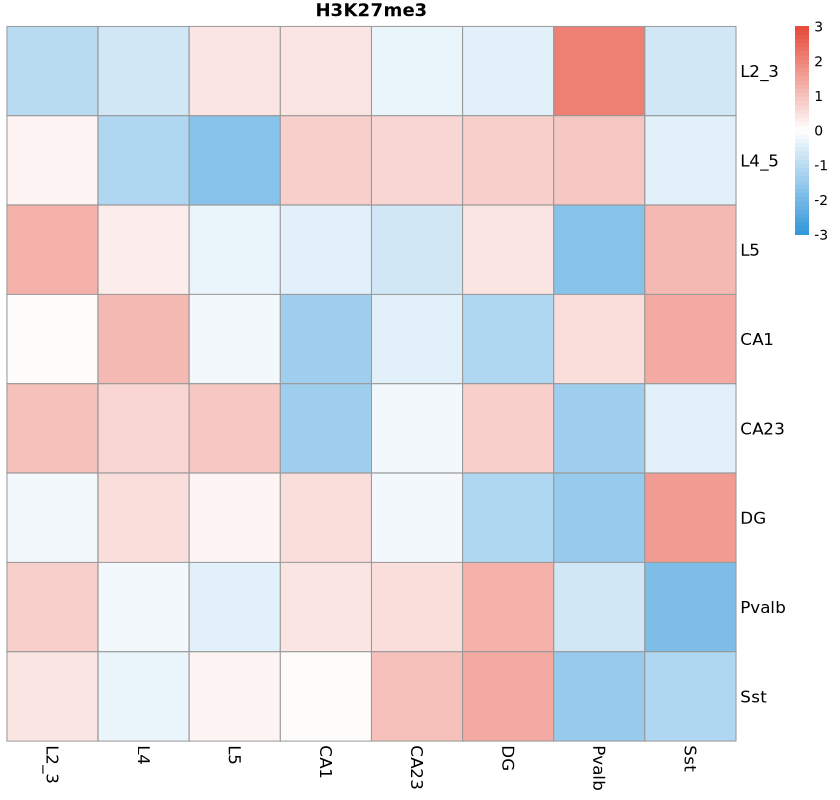

In [47]:
options(repr.plot.width = 8.4, repr.plot.height = 8, repr.plot.res = 100)
pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K27me3",
  fontsize_row = 12,
  fontsize_col = 12,
  breaks = seq(-3, 3, length.out = 51)
)

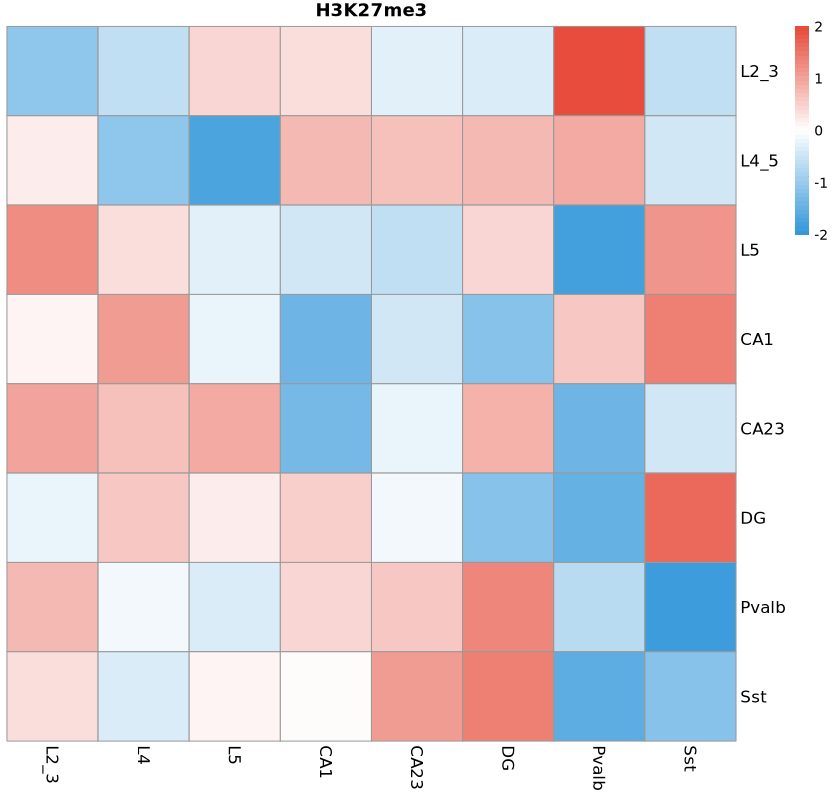

In [48]:
options(repr.plot.width = 8.4, repr.plot.height = 8, repr.plot.res = 100)
pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K27me3",
  fontsize_row = 12,
  fontsize_col = 12,
  breaks = seq(-2, 2, length.out = 51)
)

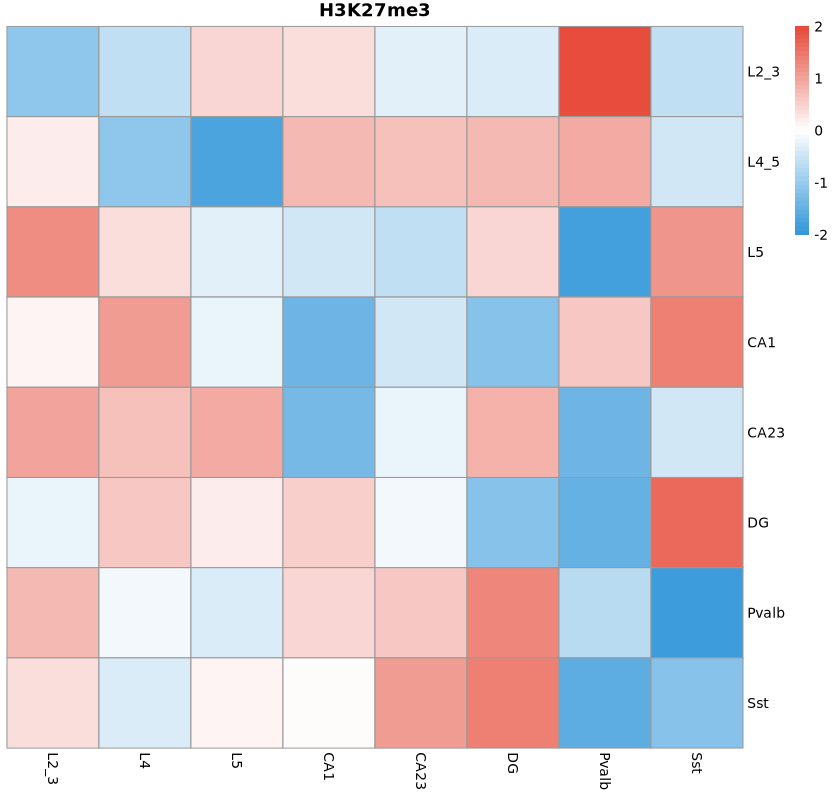

In [49]:
p1 <- pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K27me3",
  fontsize_row = 10,
  fontsize_col = 10,
  breaks = seq(-2, 2, length.out = 51)
)

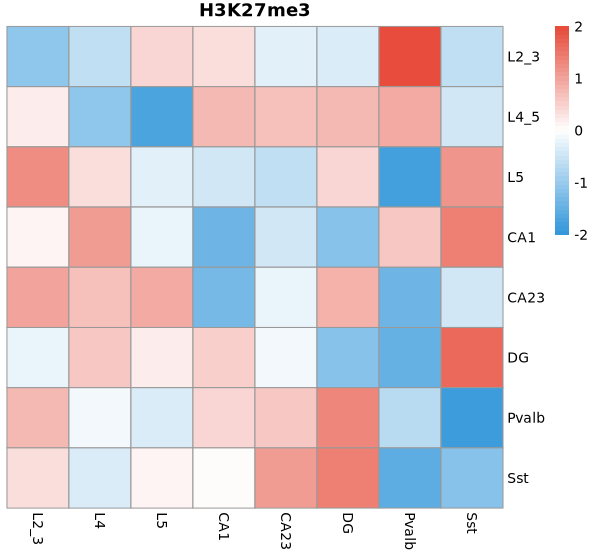

In [50]:
options(repr.plot.width = 6, repr.plot.height = 5.6, repr.plot.res = 100)
p1

In [51]:
pdf("../output/12-H3K27me3_modification_in_hyperDHMR_merge.pdf",width = 6,height = 5.6)
p1
dev.off()

png 
  2

In [ ]:
# Finished!